In [1]:
# Experiment (Visualization) note on n-gram language modeling (notebook scale but with visualization)
import torch
from sorl.gat_sim import GAT, GATConfig, BOS_TOKEN_ID
torch.set_float32_matmul_precision('high')  # Enable TF32 for ~2x speedup
# For fast training, set 'BOS_TOKEN_ID' to 15 in 'sorl/gat_sim.py' 

gat_config = GATConfig(
    vocab_sizes=[BOS_TOKEN_ID+1, 16],  # 16 abstract tokens
    n_layer=4,
    n_head=4,
    n_embd=128,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

model = GAT(gat_config)
# model = model.to("cuda")
# model = torch.compile(model)


# 1. load a small subset of the dataset (checked)
# 2. tokenize & build data loader (checked)
# 3. train with SoRL. 
# 4. visualize abstraciton dynamics (similar to copy-n-paste, but more generally on per-n-gram statistics)

In [2]:
from data.tinystory_local import TinyStoriesDataLoader, collect_rollout_statistics, AbstractionStatistics
from data.tinystory_local import visualize_dynamics
import tiktoken 

# TinyStories Dataset + GPT2 tokenizer
# -------------------------------------
num_stories = 100
max_len = 36
K = 4
loader = TinyStoriesDataLoader(num_stories=num_stories, max_len=max_len, chunk_size=K, device='cpu')

doc_len = max_len  + (max_len - 1) // K # <-- doc len contains abstract tokens
batch_size = 8
memory_span = 2 * max_len + 2
attn_blocksize = 1792
max_iterations = 2

# ---- stat collection ---
abs_stats = AbstractionStatistics(
    n_doc=num_stories,
    n_abs=doc_len - max_len,
    abs_vocab_size=model.vocab_sizes[1],
    device=model.device
)

# --- tokenizer --- 
enc = tiktoken.get_encoding("gpt2")
eot = enc._special_tokens['<|endoftext|>']

Loading 100 stories from TinyStories train...
Loaded 100 stories, 3600 tokens total, 0.01 MB
Collected 726 unique 4-chunks


In [ ]:
# train SoRL 

# Dynamic Visualization of SoRL
# 1. select-one SoRL

from sorl.neo_utils import sorl_rollout_v2, select_best_per_doc, sorl_evaluate_v2, compute_vocab_utilization_rate
from sorl.topo import orthogonalize_abs_param
from collections import defaultdict
from sorl.info import SoRLLoss

# --- orthogonal initialization on abs param --- 
orthogonalize_abs_param(model, do_wte=True, do_head=True)

loss_fn = SoRLLoss(model.vocab_sizes[1], decay=0.8, target_vocab_util=0.9)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)
n = 2
temperature = torch.tensor([0.0, 5.0], device=model.device)
num_steps = 400 
alpha_abs = 0.1
alpha_marg_ent = 1.0
record = defaultdict(list)
img_frames = []

for step in range(num_steps): 

    optimizer.zero_grad()

    tokens, doc_ids = loader.get_batch(batch_size)

    with torch.no_grad(): 
        # --- breakdown of SoRL search (select one per-document) ---
        search_data, search_ppt = sorl_rollout_v2(tokens, model, n=n, K=K, 
                                    max_iterations=max_iterations,
                                    memory_span=memory_span,
                                    attn_blocksize=attn_blocksize,
                                    temperature=temperature,
                                    truncate_seq_len=False)
        search_ppt = search_ppt.reshape(search_data.shape[0], -1)

        levels = (search_data >= model.vocab_sizes[0]).long()
        best_data, best_ppt, best_ppt_advantage = select_best_per_doc(search_data, search_ppt, levels, model)

    # --- compute loss --- 
    traj_loss, abs_loss, marg_ent, _ = loss_fn(best_data, model, memory_span, attn_blocksize)
    loss = traj_loss + alpha_abs * abs_loss - alpha_marg_ent * marg_ent

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, 10.0], device=model.device)
            val_tokens, val_adv, traj_loss, abs_loss, abs_logits, abs_tokens = sorl_evaluate_v2(tokens, model, n=2, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                     truncate_seq_len=False)
            _, _, marg_ent, cond_ent = loss_fn(val_tokens, model, memory_span, attn_blocksize)
            vocab_util = compute_vocab_utilization_rate(val_tokens, model)
            abs_stats.update(abs_logits, abs_tokens, doc_ids)
            
            record['vocab_util'].append(vocab_util * 100)
            record['search_adv'].append(val_adv.item() * 100)
            record['abs_loss'].append(abs_loss.item())
            record['traj_loss'].append(traj_loss.item())
            record['marg_ent'].append(marg_ent.item())
            record['cond_ent'].append(cond_ent.item())
        print(f"\nvalidation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | vocab util: {vocab_util * 100:.2f}%  | marg_ent: {marg_ent.item():.2f} | cond_ent: {cond_ent.item():.2f}")
        
        img = visualize_dynamics(abs_stats, loader, model, enc, K)
        img_frames.append(img)


validation step 0 | traj_loss: 10.75 | abs_loss: 8.23 | search adv: 0.07% | vocab util: 87.50%  | marg_ent: 2.67 | cond_ent: 2.14

validation step 2 | traj_loss: 10.65 | abs_loss: 6.62 | search adv: 0.14% | vocab util: 81.25%  | marg_ent: 2.67 | cond_ent: 1.62

validation step 4 | traj_loss: 10.46 | abs_loss: 5.90 | search adv: 0.12% | vocab util: 81.25%  | marg_ent: 2.60 | cond_ent: 1.66

validation step 6 | traj_loss: 10.16 | abs_loss: 5.34 | search adv: 0.11% | vocab util: 68.75%  | marg_ent: 2.56 | cond_ent: 1.74

validation step 8 | traj_loss: 9.76 | abs_loss: 5.16 | search adv: 0.06% | vocab util: 56.25%  | marg_ent: 2.51 | cond_ent: 1.94

validation step 10 | traj_loss: 9.45 | abs_loss: 4.87 | search adv: 0.05% | vocab util: 56.25%  | marg_ent: 2.51 | cond_ent: 2.05

validation step 12 | traj_loss: 9.05 | abs_loss: 4.36 | search adv: 0.06% | vocab util: 37.50%  | marg_ent: 2.50 | cond_ent: 2.07

validation step 14 | traj_loss: 8.73 | abs_loss: 3.72 | search adv: 0.06% | vocab u

In [4]:
if len(img_frames) > 0:
    img_frames[0].save(
        'tinystories_dynamics (select-best per abs SoRL + 1.0 marg_ent).gif',
        save_all=True,
        append_images=img_frames[1:],
        duration=500,  # milliseconds per frame
        loop=0  # 0 = infinite loop
    )
    print(f"Saved GIF with {len(img_frames)} frames")

Saved GIF with 200 frames


In [ ]:
from data.tinystory_local import * 

doc_ids = torch.arange(0, 100, 25)
tokens, _ = loader.get_specific(doc_ids)
abs_tokens = abs_stats.abs_seqs[doc_ids]
abs_tokens[abs_tokens == 0] += BOS_TOKEN_ID
valid_ids = torch.arange(0, doc_ids.shape[0]).tolist()
img_align = visualize_alignment_compact(tokens, abs_tokens, doc_ids, model, enc, K=4, doc_idx=valid_ids, max_chunks=8)

img_dist = visualize_distribution(abs_stats, step=step)

cs_sim = abs_stats.compute_cross_doc_logit_sim()
img_cluster = visualize_clustering(cs_sim)

# stitch the 3 together (img_align to the left, right top img_cluster, right bottom img_dist)

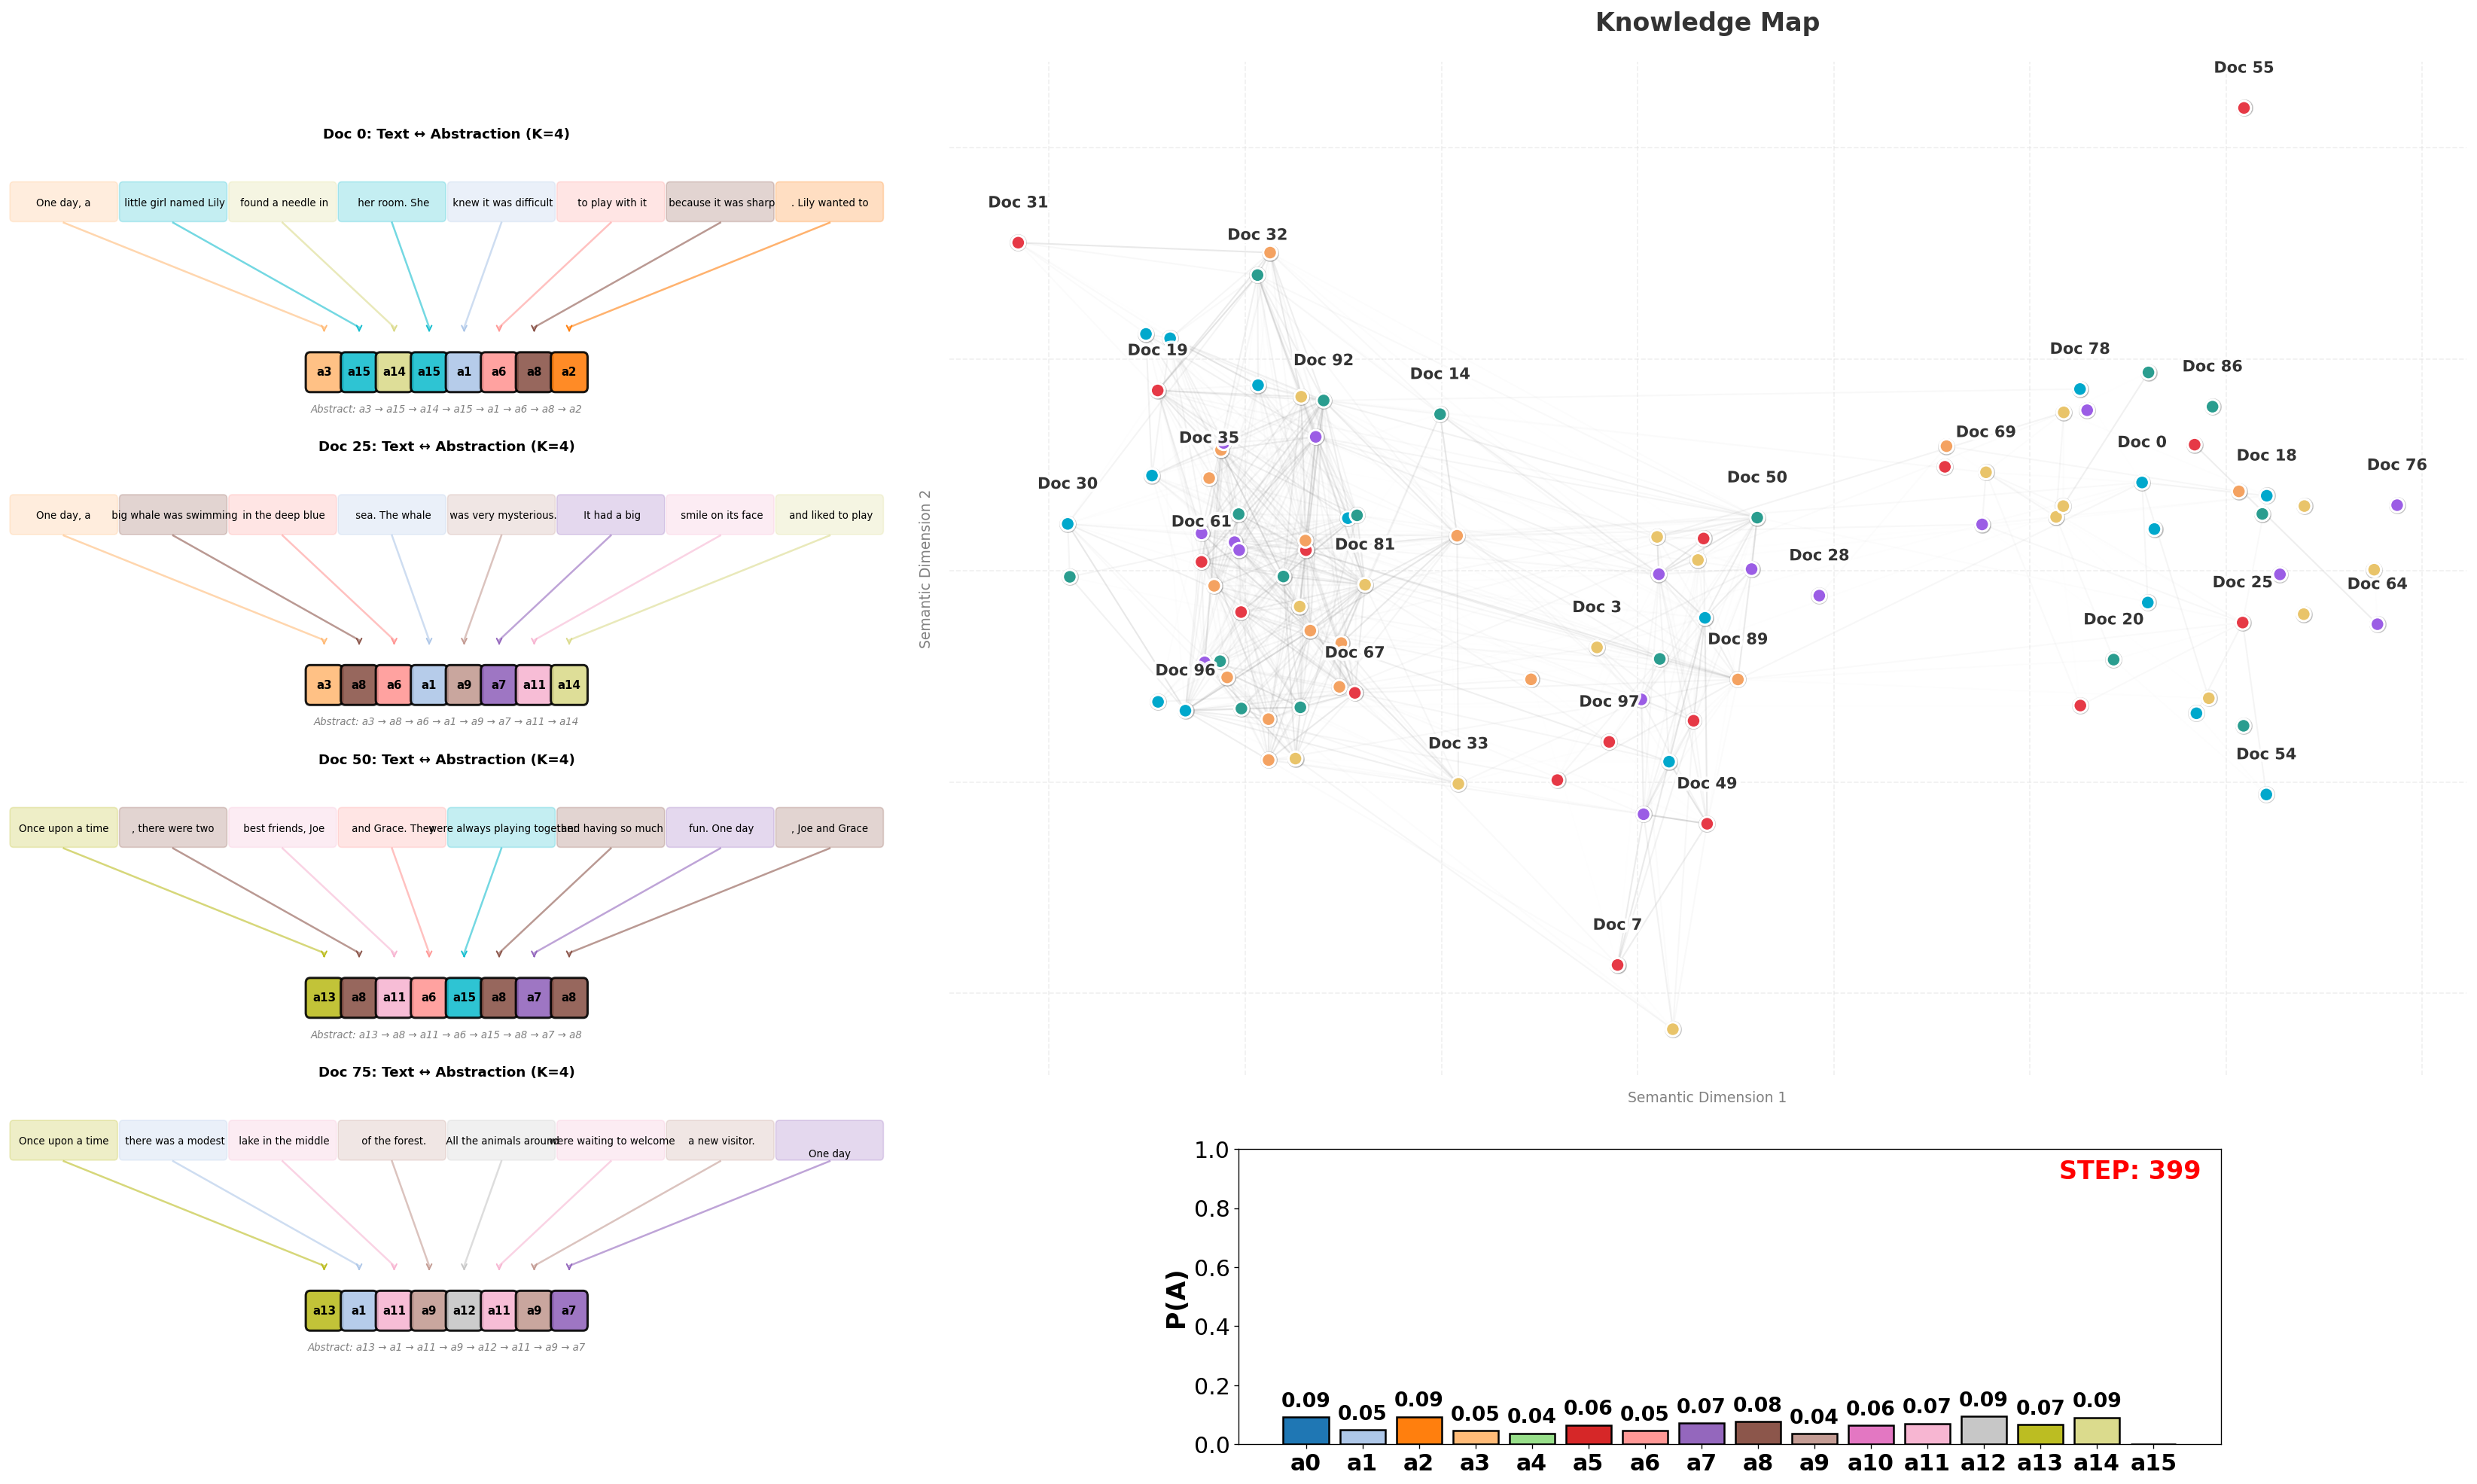

In [34]:
def visualize_dashboard(img_align, img_cluster, img_dist, padding=20):
    """
    Creates a balanced dashboard:
    +---------------------+-----------------------+
    |                     |                       |
    |                     |     CLUSTERING        |
    |      ALIGNMENT      |       (Top R)         |
    |       (Left)        |                       |
    |                     +-----------------------+
    |                     |     DISTRIBUTION      |
    |                     |      (Bottom R)       |
    +---------------------+-----------------------+
    """
    from PIL import Image
    
    # 1. Resize Right Column to match Widths
    # Make dist plot same width as cluster plot for neat column
    target_width = max(img_cluster.width, img_dist.width)
    
    # Resize keeping aspect ratio (optional, or just paste centered)
    # Actually, let's just center them in the right column canvas
    
    right_height = img_cluster.height + img_dist.height + padding
    
    # 2. Determine Canvas Size
    # We want alignment (left) to take up full height if possible, or center it
    total_height = max(img_align.height, right_height)
    total_width = img_align.width + target_width + padding
    
    canvas = Image.new('RGB', (total_width, total_height), (255, 255, 255))
    
    # 3. Paste Left (Alignment) - Vertically Centered
    y_align = (total_height - img_align.height) // 2
    canvas.paste(img_align, (0, y_align))
    
    # 4. Paste Right Column
    x_right = img_align.width + padding
    
    # Cluster Map (Top Right)
    # If cluster map is taller than half, this might overlap. 
    # Let's stack them properly starting from top or center the whole stack.
    
    # Center the right stack vertically
    y_stack_start = (total_height - right_height) // 2
    
    # Cluster
    # Center horizontally in right column
    x_cluster = x_right + (target_width - img_cluster.width) // 2
    canvas.paste(img_cluster, (x_cluster, y_stack_start))
    
    # Distribution
    # Center horizontally in right column
    x_dist = x_right + (target_width - img_dist.width) // 2
    y_dist = y_stack_start + img_cluster.height + padding
    canvas.paste(img_dist, (x_dist, y_dist))
    
    return canvas

# Usage
final_img = visualize_dashboard(img_align, img_cluster, img_dist)
display(final_img)

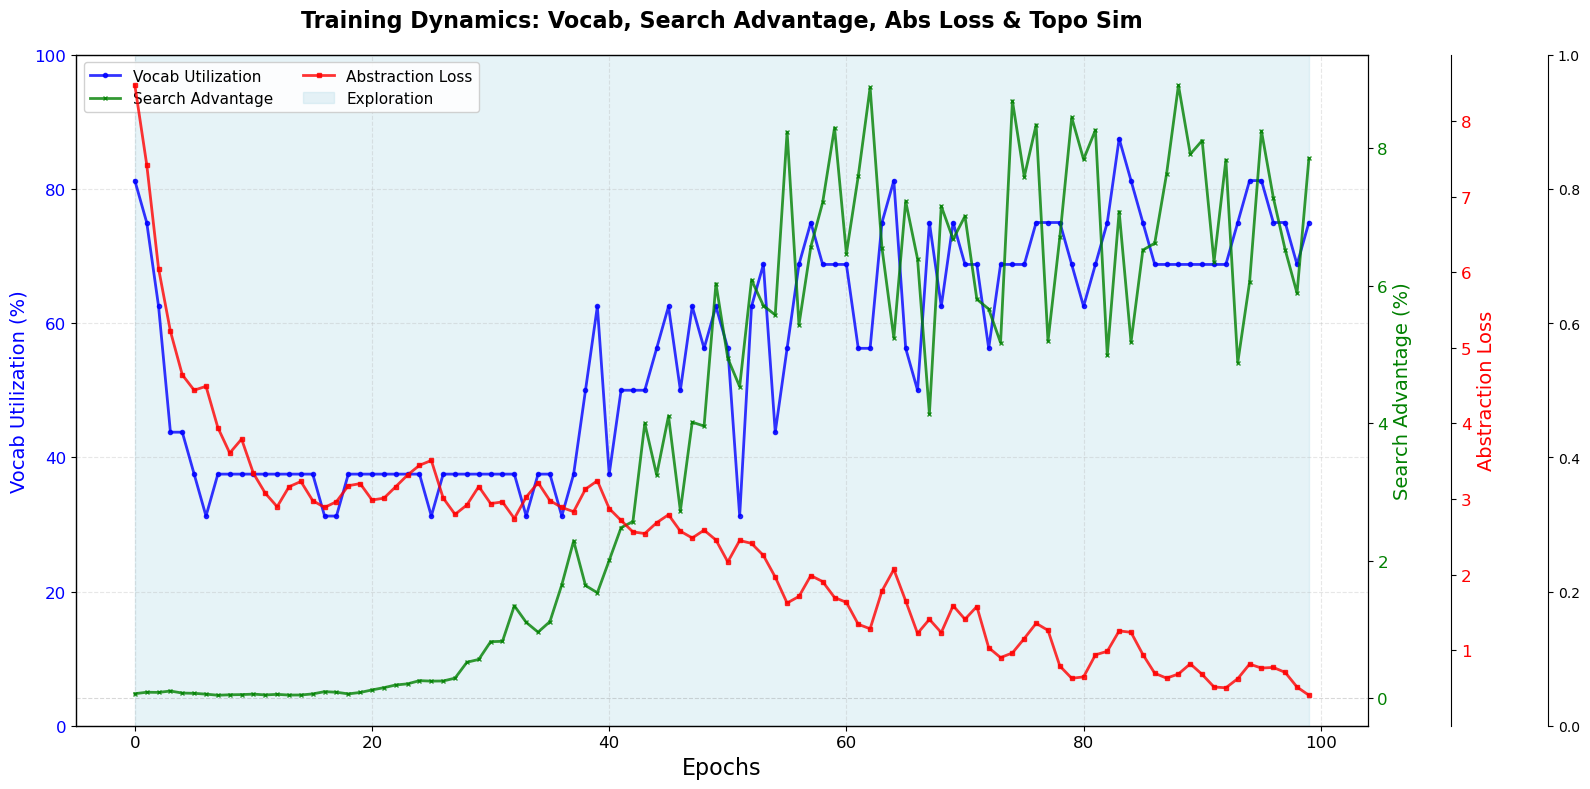

In [4]:
from sorl.stat import plot_training_metrics_combined

plot_training_metrics_combined(record)

In [5]:
import math 
math.log(6)

1.791759469228055

In [ ]:
# Idea #1. 
# - we need to visualize the marginal distribution of abstract logits, instead of just inspecting on its entropy

# Request #2. 
# - per 'story' (it's fine to check on train-stories for now) visualization of 'marginal logit' distribution
# - cross 'story' distance matrix (logit cosine similarity or edit distance)

